# Exporting and Importing from OpenQASM

In this tutorial, we will explore the process of exporting Workbench programs to OpenQASM.

As we've seen in the [earlier tutorial](./Configuring-Execution.ipynb), Workbench programs are compiled and executed via the filter pipeline - a sequence of filters that process quantum instructions. One type of utility filter is *exporters* - classical programs that convert the Workbench instructions to instructions which may be used in other software.

As the program runs, it emits QPU instructions, which are recorded in the exporter filter. When desired, they are converted into OpenQASM format. Note that only the circuit is exported; any high-level classical logic (the Python program) is not included in the OpenQASM data.

In this tutorial, we'll demonstrate the process of converting a Workbench program into OpenQASM.

> Note that importing OpenQASM code to Workbench requires `antlr4-python3-runtime` to be installed. You can install this package using `pip install antlr4-python3-runtime`.

## Exporting simple circuits to OpenQASM

Consider the following simple circuit. We'll run it as we normally would, *except* that we'll attach an instance of the `QasmExportFilter`, so that we can export any circuit we run into OpenQASM format.

2 + 1 = 3


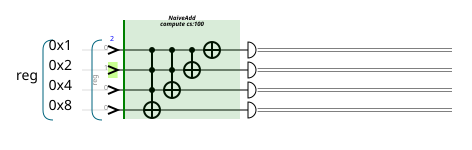

In [1]:
from psiqdk.workbench import QPU, Qubits
from psiqdk.workbench.integrations.qasm import QasmExportFilter, QasmString

export_filter = QasmExportFilter()
n = 4
qpu = QPU(num_qubits=n, pre_filters=[export_filter])
reg = Qubits(n, "reg", qpu)

reg.write(2)
reg += 1
result = reg.read()

print(f"2 + 1 = {result}")

qpu.nop(repeat=10)
qpu.draw(show_qubricks=True)

The program has been run, and the measurements provided the correct result. In addition, our `export_filter` has recorded all of the instructions we executed. We can call `get_qasm_string()` on it directly to see what it collected.

In [2]:
qasm_string = export_filter.get_qasm_string()
print(qasm_string)

OPENQASM 3;
include "stdgates.inc";

qubit[4] q;
bit[4] c;

let reg_1 = q[0:4];
reset q[0];
reset q[1];
reset q[2];
reset q[3];
x q[1];
barrier q;
// [qbk:[NaiveAdd]][cs:100] (compute start)
ctrl @ ctrl @ ctrl @ x q[0], q[1], q[2], q[3];
ctrl @ ctrl @ x q[0], q[1], q[2];
ctrl @ x q[0], q[1];
x q[0];
barrier q;
// [qbk:[NaiveAdd]][cs:100] (compute end)
c[0] = measure q[0];
c[1] = measure q[1];
c[2] = measure q[2];
c[3] = measure q[3];


Close inspection reveals that there's not *exactly* a 1-to-1 match between our original instructions and the exported instructions. Workbench is doing its best to match the output functionality of OpenQASM, in this case by converting `reg.write(2)` into the equivalent of `reg.write(0)` and then `reg[1].x()`

## Importing OpenQASM code

This OpenQASM program can be loaded using the Workbench `QasmString` utility class and the Workbench `QPU` object can run the program.

2 + 1 = [1, 2, 0, 0]
2 + 1 = 3


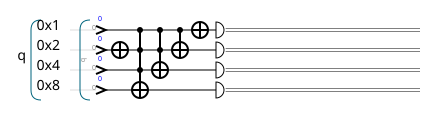

In [3]:
qpu = QPU(num_qubits=n)
qasm_obj = QasmString(qasm_string)

result = qasm_obj.add_operations_to_qpu(qpu)

print(f"2 + 1 = {result}")
print(f"2 + 1 = {sum(result)}")

qpu.nop(repeat=10)
qpu.draw()

You can see that the program is essentially the same as our original, with some adjustments made to handle the `write()` instruction.

Note that the output of the `add_operations_to_qpu()` method is a list. For each qubit measurement (in the order that they were performed), the list entry is either $0$ (if the output was 0) or $2^n$, where $n$ is the index of the qubit measured. Since in this simple program we're reading out an integer in little-endian encoding, we can simply sum the results to get the final answer.

Note that the logic of what the measurements *mean*, and how to interpret them, is in the original Python code and not contained in the OpenQASM circuit.

## More complicated gates

Consider the following program, which uses more complicated gates such as multi-controlled gates:

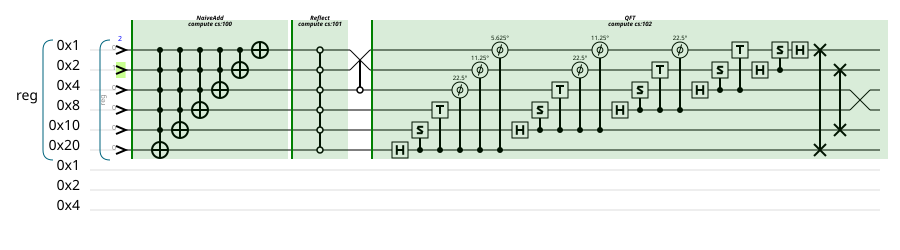

In [4]:
from psiqdk.workbench import QPU, Qubits
from psiqdk.workbench.integrations.qasm import QasmExportFilter, QasmString
import numpy as np

def user_program(reg:Qubits):
    reg.write(2)
    reg += 1
    (~reg).reflect()
    reg[0].swap(reg[1], ~reg[2])
    reg.QFT()

export_filter = QasmExportFilter()
qpu = QPU(num_qubits=9, pre_filters=[export_filter])
reg = Qubits(6, "reg", qpu)

user_program(reg)

expected_psi = qpu.pull_state()

qpu.draw(show_qubricks=True)

Let's see what the OpenQASM exporter turns that into:

In [5]:
qasm_string = export_filter.get_qasm_string()
print(qasm_string)

OPENQASM 3;
include "stdgates.inc";

qubit[9] q;

let reg_1 = q[0:6];
reset q[0];
reset q[1];
reset q[2];
reset q[3];
reset q[4];
reset q[5];
x q[1];
barrier q;
// [qbk:[NaiveAdd]][cs:100] (compute start)
ctrl @ ctrl @ ctrl @ ctrl @ ctrl @ x q[0], q[1], q[2], q[3], q[4], q[5];
ctrl @ ctrl @ ctrl @ ctrl @ x q[0], q[1], q[2], q[3], q[4];
ctrl @ ctrl @ ctrl @ x q[0], q[1], q[2], q[3];
ctrl @ ctrl @ x q[0], q[1], q[2];
ctrl @ x q[0], q[1];
x q[0];
barrier q;
// [qbk:[NaiveAdd]][cs:100] (compute end)
barrier q;
// [qbk:[Reflect]][cs:101] (compute start)
x q[5];
negctrl @ negctrl @ negctrl @ negctrl @ negctrl @ z q[0], q[1], q[2], q[3], q[4], q[5];
x q[5];
barrier q;
// [qbk:[Reflect]][cs:101] (compute end)
negctrl @ swap q[2], q[0], q[1];
barrier q;
// [qbk:[QFT]][cs:102] (compute start)
h q[5];
ctrl @ s q[5], q[4];
ctrl @ t q[5], q[3];
ctrl @ p(0.39269908169872414) q[5], q[2];
ctrl @ p(0.19634954084936207) q[5], q[1];
ctrl @ p(0.09817477042468103) q[5], q[0];
h q[4];
ctrl @ s q[4], q[3];
c

The export worked, so let's feed the OpenQASM back through Workbench and see if we get equivalent gates and a matching state.

The state matches!


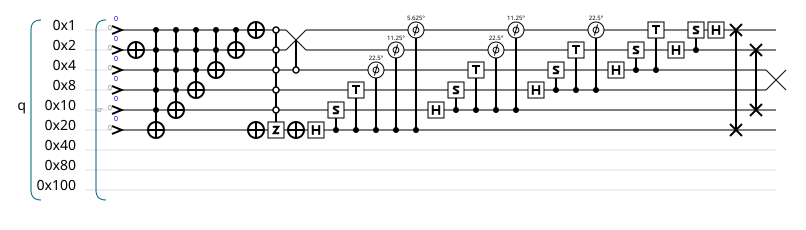

In [6]:
qpu = QPU(num_qubits=9)
qasm_obj = QasmString(qasm_string)

result = qasm_obj.add_operations_to_qpu(qpu)

if np.allclose(expected_psi, qpu.pull_state()):
    print("The state matches!")
else:
    print("The state doesn't match.")

qpu.draw()

Nice. That looks good. Suppose next we want to use a built-in Workbench compilation filter to break these gates down into more basic ones. We can do it by inserting the compilation filter *before* the exporter filter. That way, the output of the compilation step is exported.

The state matches!


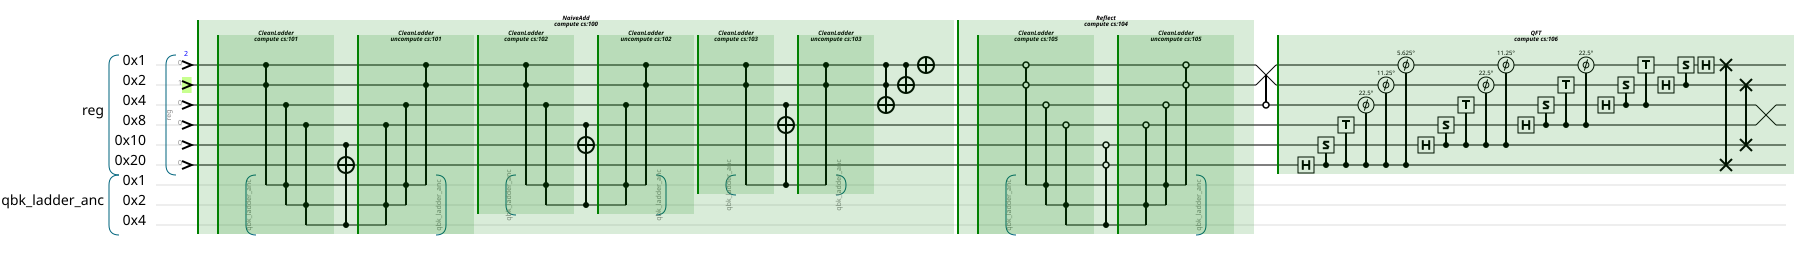

OPENQASM 3;
include "stdgates.inc";

qubit[9] q;

let reg_1 = q[0:6];
reset q[0];
reset q[1];
reset q[2];
reset q[3];
reset q[4];
reset q[5];
x q[1];
barrier q;
// [qbk:[NaiveAdd]][cs:100] (compute start)
barrier q;
// [qbk:[CleanLadder]][cs:101] (compute start)
let qbk_ladder_anc_2 = q[6:9];
reset q[6];
ctrl @ ctrl @ x q[0], q[1], q[6];
reset q[7];
ctrl @ ctrl @ x q[2], q[6], q[7];
reset q[8];
ctrl @ ctrl @ x q[3], q[7], q[8];
barrier q;
// [qbk:[CleanLadder]][cs:101] (compute end)
ctrl @ ctrl @ x q[4], q[8], q[5];
barrier q;
// [qbk:[CleanLadder]][cs:101] (uncompute start)
ctrl @ ctrl @ x q[3], q[7], q[8];
reset q[8];
ctrl @ ctrl @ x q[2], q[6], q[7];
reset q[7];
ctrl @ ctrl @ x q[0], q[1], q[6];
reset q[6];
barrier q;
// [qbk:[CleanLadder]][cs:101] (uncompute end)
barrier q;
// [qbk:[CleanLadder]][cs:102] (compute start)
let qbk_ladder_anc_3 = q[6:8];
reset q[6];
ctrl @ ctrl @ x q[0], q[1], q[6];
reset q[7];
ctrl @ ctrl @ x q[2], q[6], q[7];
barrier q;
// [qbk:[CleanLadder]][cs:102]

In [7]:
export_filter = QasmExportFilter()
qpu = QPU(num_qubits=9, pre_filters=['>>clean-ladder-filter>>', export_filter])
reg = Qubits(6, "reg", qpu)

user_program(reg)

if np.allclose(expected_psi, qpu.pull_state()):
    print("The state matches!")
else:
    print("The state doesn't match.")

qpu.draw(show_qubricks=True)

qasm_string = export_filter.get_qasm_string()
print(qasm_string)

Now we can test it using our previous method.

The state matches!


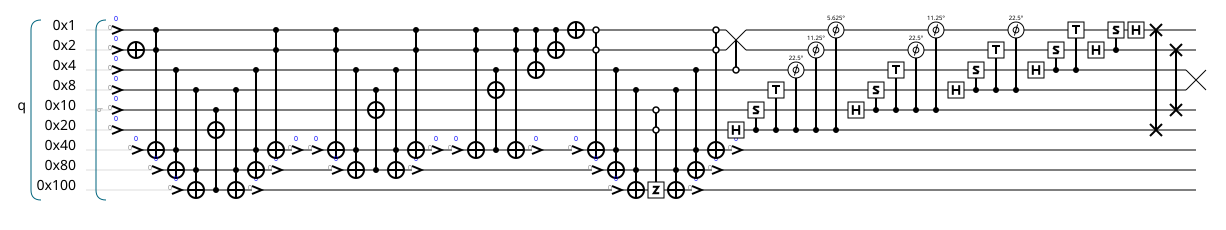

In [8]:
qpu = QPU(num_qubits=9)
qasm_obj = QasmString(qasm_string)

result = qasm_obj.add_operations_to_qpu(qpu)

if np.allclose(expected_psi, qpu.pull_state()):
    print("The state matches!")
else:
    print("The state doesn't match.")

qpu.draw()

## Some caveats and limitations

- Not all QPU operations are supported by the `QasmExportFilter`. Using the Workbench compilation filters can help make more elaborate programs export correctly.
- High-level program logic cannot be exported into in OpenQASM, and so is missing from the exported and re-imported program.

## Next steps

In this tutorial, you've learned to use the Workbench OpenQASM exporter, and also how to import OpenQASM gates into Workbench. As a next step, you may want to try running exported programs using other quantum tools you're familiar with.